# 결측치

In [3]:
import pandas as pd
import numpy as np

In [5]:
df = pd.DataFrame(
    {
        "gender": ["M", "F", np.nan, "M", "F"], 
        "score": [5, 4, 3, 4, np.nan]
    }
)
df

,gender,score
0,M,5.0
1,F,4.0
2,NaN,3.0
3,M,4.0
4,F,NaN


In [6]:
df["score"].sum(), df["score"].mean()

(np.float64(16.0), np.float64(4.0))

# 결측치 확인

In [8]:
pd. isna(df)

,gender,score
0,False,False
1,False,False
2,True,False
3,False,False
4,False,True


In [9]:
pd.isna(df)

,gender,score
0,False,False
1,False,False
2,True,False
3,False,False
4,False,True


In [11]:
pd.isna(df).sum()

gender    1
score     1
dtype: int64

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   gender  4 non-null      str    
 1   score   4 non-null      float64
dtypes: float64(1), str(1)
memory usage: 212.0 bytes


# 결측치 제거 

In [17]:
df.dropna(subset="score")

,gender,score
0,M,5.0
1,F,4.0
2,NaN,3.0
3,M,4.0


In [18]:
df.dropna()

,gender,score
0,M,5.0
1,F,4.0
3,M,4.0


In [20]:
exam = pd.read_csv("./Data/exam.csv")
exam.shape

(20, 5)

In [21]:
exam.loc[[2, 7, 14], ['math']] = np.nan

# 결측치 대체 

In [23]:
exam

,id,nclass,math,english,science
0,1,1,50.0,98,50
1,2,1,60.0,97,60
2,3,1,NaN,86,78
3,4,1,30.0,98,58
4,5,2,25.0,80,65
5,6,2,50.0,89,98
6,7,2,80.0,90,45
7,8,2,NaN,78,25
8,9,3,20.0,98,15
9,10,3,50.0,98,45


In [25]:
exam["math"].mean()

np.float64(55.23529411764706)

In [27]:
exam["math"].describe()

count    17.000000
mean     55.235294
std      19.721592
min      20.000000
25%      46.000000
50%      50.000000
75%      65.000000
max      89.000000
Name: math, dtype: float64

In [30]:
exam["math"].fillna(55)

0     50.0
1     60.0
2     55.0
3     30.0
4     25.0
5     50.0
6     80.0
7     55.0
8     20.0
9     50.0
10    65.0
11    45.0
12    46.0
13    48.0
14    55.0
15    58.0
16    65.0
17    80.0
18    89.0
19    78.0
Name: math, dtype: float64

In [32]:
exam.isna().sum()

id         0
nclass     0
math       3
english    0
science    0
dtype: int64

In [33]:
exam.bfill() #뒤에 값을 땡겨온다 
exam.ffill() #앞에 값을 땡겨온다

,id,nclass,math,english,science
0,1,1,50.0,98,50
1,2,1,60.0,97,60
2,3,1,60.0,86,78
3,4,1,30.0,98,58
4,5,2,25.0,80,65
5,6,2,50.0,89,98
6,7,2,80.0,90,45
7,8,2,80.0,78,25
8,9,3,20.0,98,15
9,10,3,50.0,98,45


# 이상치 

In [36]:
df = pd.DataFrame(
    {
        "gender": [1, 2, 1, 3, 2, 1],
        "score": [5, 4, 3, 4, 2, 6]
    }
)
df

,gender,score
0,1,5
1,2,4
2,1,3
3,3,4
4,2,2
5,1,6


In [38]:
df["gender"].value_counts(sort = False)

gender
1    3
2    2
3    1
Name: count, dtype: int64

In [39]:
df["score"].value_counts(sort = False).sort_index()

score
2    1
3    1
4    2
5    1
6    1
Name: count, dtype: int64

In [40]:
mpg = pd.read_csv("./Data/mpg.csv")

In [42]:
import seaborn as sns 

<Axes: ylabel='hwy'>

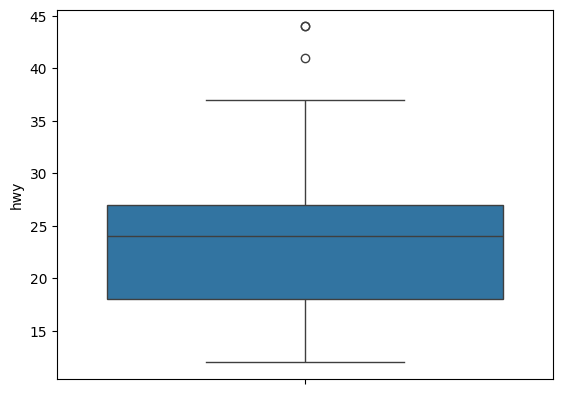

In [44]:
sns.boxplot(mpg, y = "hwy") 

In [46]:
# 극단치의 기준 
pct25 = mpg["hwy"].quantile(.25)
pct25 

np.float64(18.0)

In [47]:
pct75 = mpg["hwy"].quantile(.75)
pct75

np.float64(27.0)

In [49]:
#IQR 
iqr = pct75 - pct25 
iqr

np.float64(9.0)

In [50]:
#하한, 상한 값 구하기 
pct25 -1.5 * iqr 

np.float64(4.5)

In [51]:
# 상한 값 구하기 
pct75 + 1.5 * iqr

np.float64(40.5)

# 극단치를 처리

In [54]:
# 4.5 ~ 40.5 범위를 벗어나는 값 
mpg["hwy"] = np.where((mpg["hwy"] < 4.5) | (mpg["hwy"] > 40.5), np.nan, mpg["hwy"])
mpg["hwy"].isna().sum()

np.int64(3)

In [59]:
mpg.dropna(subset = "hwy") \
    .groupby("drv") \
    .agg(mean_hwy = ("hwy", "mean"))

,mean_hwy
drv,
4,19.174757
f,27.728155
r,21.000000


In [58]:
mpg.groupby("drv").agg(mean_hwy = ("hwy", "mean"))

,mean_hwy
drv,
4,19.174757
f,27.728155
r,21.000000


In [60]:
yes24 = pd.read_csv("./Data/yes24/yes24_ai.csv")
yes24.shape

(1200, 11)

In [100]:
kyobo = pd.read_csv("./Data/kyobobook/kyobobook_data.csv")
kyobo.shape

(433, 10)

In [101]:
yes24.head()

,제목,저자,출판사,발행일,정가,판매가,리뷰 수,판매지수,상세 정보,설명,상세 페이지 URL
0,요즘 바이브 코딩 클로드 코드 완벽 가이드,최지호,골든래빗,2025년 09월,24000.0,21600,9,"30,381",NaN,★ 200달러 MAX 플랜으로 매일 10시간씩 실험하여 얻은 노하우를 모두 담았다!...,https://www.yes24.com/product/goods/151850127
1,"AI 시대의 질문력, 프롬프트 엔지니어링",류한석,코리아닷컴(Korea.com),2025년 08월,27000.0,24300,25,"22,371",NaN,대한민국 최고의 대기업과 공공기관이 선택한 프롬프트 엔지니어링 교과서당신의 질문력이...,https://www.yes24.com/product/goods/150566390
2,요즘 교사를 위한 AI 수업 활용 가이드 with 2022 개정 교육과정,"박진환, 공지훈, 서원진",한빛미디어,2025년 05월,20000.0,18000,58,"52,032",NaN,"2022 개정 교육과정에 맞춘 실전 에듀테크 활용서챗GPT, 구글 스프레드시트, 캔...",https://www.yes24.com/product/goods/145426898
3,밑바닥부터 만들면서 배우는 LLM,세바스찬 라시카 /박해선 역,길벗,2025년 09월,40000.0,36000,14,"13,164",NaN,"한 줄 한 줄 코드를 따라가다 보면, 나만의 GPT가 완성된다!GPT를 밑바닥부터 ...",https://www.yes24.com/product/goods/154099735
4,AI 시대의 필수 문해력 수업,조기준,아토북,2025년 09월,17500.0,15750,27,"20,259",NaN,"국어 문제를 푸는 훈련이 아니라,태도와 커리어를 결정하는 힘!“AI 시대, 당신의 ...",https://www.yes24.com/product/goods/153901970


In [68]:
kyobo.head()

,도서명,저자,출판사,발행일,정가,판매가,리뷰 수,페이지 수,도서 소개,상품ID
0,바이브 코딩 너머 개발자 생존법,애디 오스마니,한빛미디어,20251107,23000.0,20700,0,NaN,"『바이브 코딩 너머 개발자 생존법』은 AI가 코드를 대신 작성하는 시대, 개발자가 ...",S000218400836
1,구글 스프레드시트 실전 가이드북,김동호 외,씨마스21,20260105,22000.0,19800,0,NaN,새 학기 시작에 필요한 학급 기초 자료를 만드는 업무부터 학기 마무리 성적 자동 완...,S000218365608
2,된다! 하루 만에 끝내는 제미나이 활용법,권서림,이지스퍼블리싱,20251117,20000.0,18000,0,NaN,이 책은 AI에 쉽게 적응하고 싶은 초보자를 위한 제미나이 입문서이다. AI 활용에...,S000218358453
3,핸즈온 바이브 코딩: 요구사항 정의부터 리팩터링까지 직관이 아닌 원리로 익히는 실전...,정도현,한빛미디어,20251031,22000.0,19800,0,NaN,AI가 프로그래밍의 방식을 근본적으로 바꾸고 있다. 이제 개발자는 모든 코드를 직접...,S000218331435
4,챗GPT·퍼플렉시티·클로드·코파일럿·제미나이 다 잘함,이호정,리코멘드,20251110,28000.0,25200,0,NaN,"★ AI 시대, 하나로는 부족합니다! ★ 진짜 일 잘하는 AI를 찾아 퇴근이 빨라지...",S000218323853


In [102]:
df_merged = yes24.merge(kyobo, how = "inner", left_on = "제목", right_on = "도서명")
df_merged.head()

,제목,저자_x,출판사_x,발행일_x,정가_x,판매가_x,리뷰 수_x,판매지수,상세 정보,설명,...,도서명,저자_y,출판사_y,발행일_y,정가_y,판매가_y,리뷰 수_y,페이지 수,도서 소개,상품ID
0,요즘 바이브 코딩 클로드 코드 완벽 가이드,최지호,골든래빗,2025년 09월,24000.0,21600,9,"30,381",NaN,★ 200달러 MAX 플랜으로 매일 10시간씩 실험하여 얻은 노하우를 모두 담았다!...,...,요즘 바이브 코딩 클로드 코드 완벽 가이드,최지호(코드팩토리),골든래빗(주),20250901,24000.0,21600,0,NaN,이 책은 현존 최강의 코딩 AI 파트너 클로드 코드의 완벽 가이드북입니다. 현업 개...,S000217347037
1,한 걸음 앞선 개발자가 지금 꼭 알아야 할 클로드 코드,"조훈, 정찬훈",길벗,2025년 09월,26000.0,23400,9,"13,389",NaN,현장에서 바로 적용할 수 있는 클로드 코드 실전 가이드!실무에서 검증된 개발 방식 ...,...,한 걸음 앞선 개발자가 지금 꼭 알아야 할 클로드 코드,조훈 외,길벗,20250912,26000.0,23400,0,NaN,"AI와 함께 개발하는 시대, 이제 클로드 코드는 더 이상 선택이 아닌 필수 도구가 ...",S000217402731
2,된다! 하루 만에 끝내는 챗GPT 활용법,프롬프트 크리에이터,이지스퍼블리싱,2025년 06월,20000.0,18000,84,"18,657",NaN,GPT 분야 3 년 연속 베스트셀러! 최신 버전 GPT-4.1 반영!초보자도 1 시...,...,된다! 하루 만에 끝내는 챗GPT 활용법,프롬프트 크리에이터,이지스퍼블리싱,20240729,17200.0,15480,0,NaN,챗GPT 입문 바이블 《된다! 하루 만에 끝내는 챗GPT 활용법》이 2024년 GP...,S000213900214
3,된다! 하루 만에 끝내는 챗GPT 활용법,프롬프트 크리에이터,이지스퍼블리싱,2025년 06월,20000.0,18000,84,"18,657",NaN,GPT 분야 3 년 연속 베스트셀러! 최신 버전 GPT-4.1 반영!초보자도 1 시...,...,된다! 하루 만에 끝내는 챗GPT 활용법,프롬프트 크리에이터,이지스퍼블리싱,20240129,17000.0,15300,0,NaN,챗GPT 입문 분야 《된다! 하루 만에 끝내는 챗GPT 활용법》이 2024년 최신 ...,S000211913345
4,AI 엔지니어링,칩 후옌 /변성윤 역,한빛미디어,2025년 09월,40000.0,36000,1,"3,786",NaN,"최고의 AI 전문가 칩 후옌이 엔비디아, 스노클 AI, 스탠퍼드에서 쌓은 현장 경험...",...,AI 엔지니어링,칩 후옌,한빛미디어,20250930,40000.0,36000,0,NaN,“프로덕트 레벨에 맞는 설계란 무엇일까요?” 파운데이션 모델을 활용해 누구나 손쉽게...,S000217939673


In [93]:
"a" == "a" 

True

In [115]:
yes24["정제제목"] = yes24["제목"].astype(str).str.strip().str.lower() 

In [116]:
kyobo["정제제목"] = kyobo["도서명"].astype(str).str.strip().str.lower()

In [117]:
kyobo.head(2)

,도서명,저자,출판사,발행일,정가,판매가,리뷰 수,페이지 수,도서 소개,상품ID,정제제목
0,바이브 코딩 너머 개발자 생존법,애디 오스마니,한빛미디어,20251107,23000.0,20700,0,NaN,"『바이브 코딩 너머 개발자 생존법』은 AI가 코드를 대신 작성하는 시대, 개발자가 ...",S000218400836,바이브 코딩 너머 개발자 생존법
1,구글 스프레드시트 실전 가이드북,김동호 외,씨마스21,20260105,22000.0,19800,0,NaN,새 학기 시작에 필요한 학급 기초 자료를 만드는 업무부터 학기 마무리 성적 자동 완...,S000218365608,구글 스프레드시트 실전 가이드북


In [118]:
df_merged2 = yes24.merge(kyobo, how = "inner", on = "정제제목")

In [119]:
df_merged.shape, df_merged2.shape

((33, 21), (33, 22))